# Code to generate the thesis plots

To generate different plots depending on different simulations change the simulation path before the .csv filename. The last two simulations do not have the final stats inside the .csv files because of the error reported by Francesco in the group chat, however the file packet_result.csv was correctly populated and it is the one used to generate the first two plots, so we can use those simulations anyway. If you try you see that the results are very close to ones presented in the thesis.

In [1]:
# low_load_sim = "project/simulations/sim_2025-07-23_12:43:21/"
# heavy_load_sim = "project/simulations/sim_2025-07-23_16:57:06/"
# sim_base_path = "project/simulations/sim_2025-07-22_10:37:20/"

low_load_sim = "project/simulations/sim_2025-09-02_17:49:15_shortest/"
heavy_load_sim = "project/simulations/sim_2025-09-02_17:49:15_shortest/"
low_load_sim_centflow = "project/simulations/sim_2025-09-02_17:49:13_centflow/"
heavy_load_sim_centflow = "project/simulations/sim_2025-09-02_17:49:14_centflow/"


graph_path = "project/file/graph_networkx_15_nodes.json"

# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import json

## Heatmap of the fraction of bits received by each node from the other nodes in the network

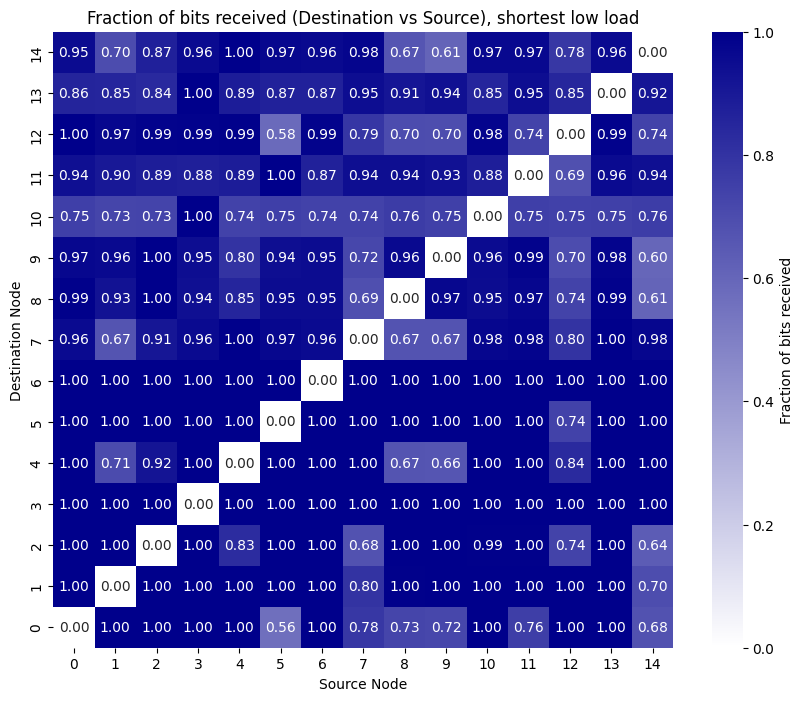

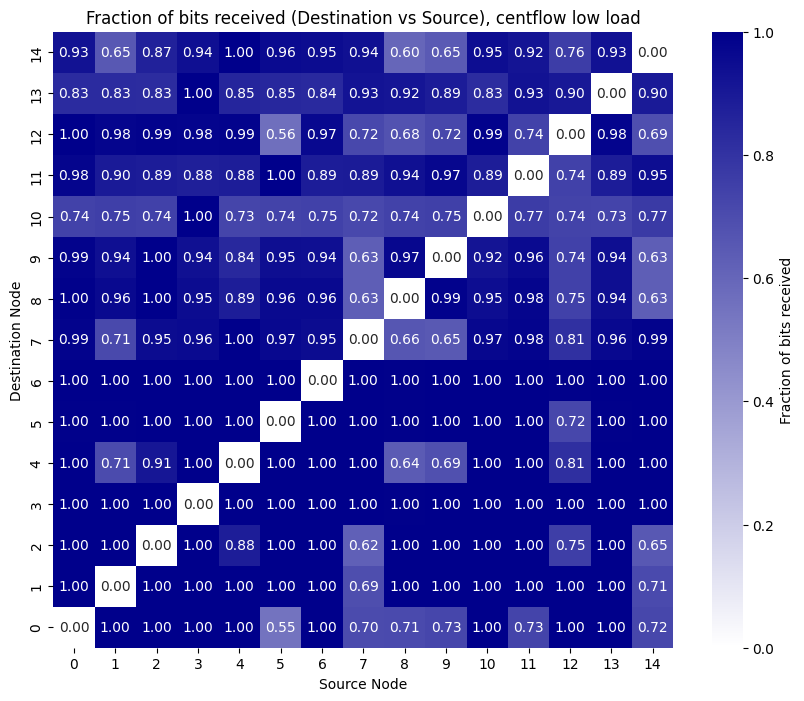

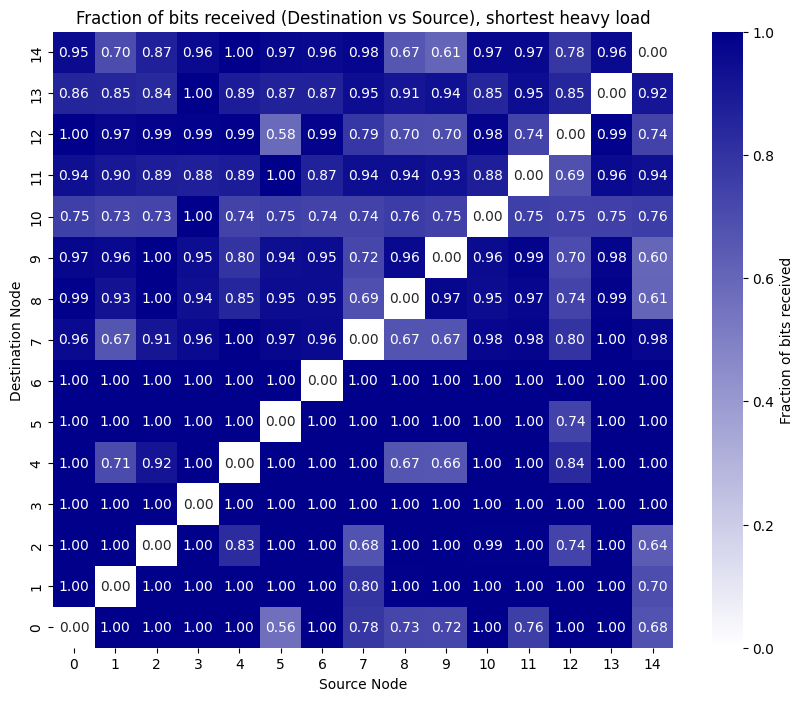

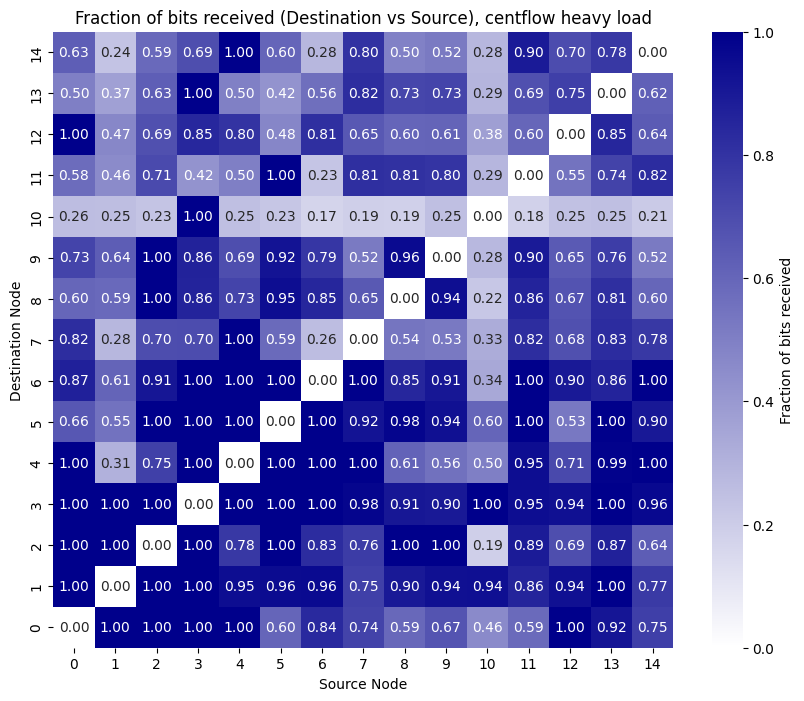

In [2]:
def heatmap(file, title:str):
    df = pd.read_csv(file)
    df["Sent"] = df["Sent"].astype(bool)
    df["Delivered"] = df["Delivered"].astype(bool)

    df_sent = df[df["Sent"] == True]

    # Group by Source and Destination and compute sent and delivered counts
    grouped = df_sent.groupby(["Source", "Destination"]).agg(
        sent_packets=("Sent", "count"),
        delivered_packets=("Delivered", "sum")
    ).reset_index()

    # Compute fraction of delivered over sent
    grouped["fraction_received"] = grouped["delivered_packets"] / grouped["sent_packets"]

    heatmap_data = grouped.pivot(index="Destination", columns="Source", values="fraction_received")
    # Replace NaN with 0
    heatmap_data = heatmap_data.fillna(0)

    # Strip 'node' prefix from rows and columns
    heatmap_data.index = heatmap_data.index.str.replace("node", "", regex=False).astype(int)
    heatmap_data.columns = heatmap_data.columns.str.replace("node", "", regex=False).astype(int)

    # Sort rows and columns
    heatmap_data = heatmap_data.sort_index(axis=0)  # rows
    heatmap_data = heatmap_data.sort_index(axis=1)  # columns

    heatmap_data = heatmap_data.reindex(index=heatmap_data.index[::-1])

    cmap = mcolors.LinearSegmentedColormap.from_list("white_to_darkblue", ["white", "#00008B"])
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Fraction of bits received"}
    )

    plt.title(f"Fraction of bits received (Destination vs Source), {title}")
    plt.xlabel("Source Node")
    plt.ylabel("Destination Node")
    plt.show()

heatmap(f"{low_load_sim}packet_result.csv", "shortest low load")
heatmap(f'{low_load_sim_centflow}packet_result.csv', "centflow low load")
heatmap(f"{heavy_load_sim}packet_result.csv", "shortest heavy load")
heatmap(f'{heavy_load_sim_centflow}packet_result.csv', "centflow heavy load")

## Number of received bits for each node

Number of correctly received packets per destination node:
Destination
0     7721
1     8756
2     8355
3     9329
4     8167
5     9058
6     9380
7     8082
8     8028
9     7940
10    7221
11    8497
12    7664
13    8522
14    7819
Name: count, dtype: int64


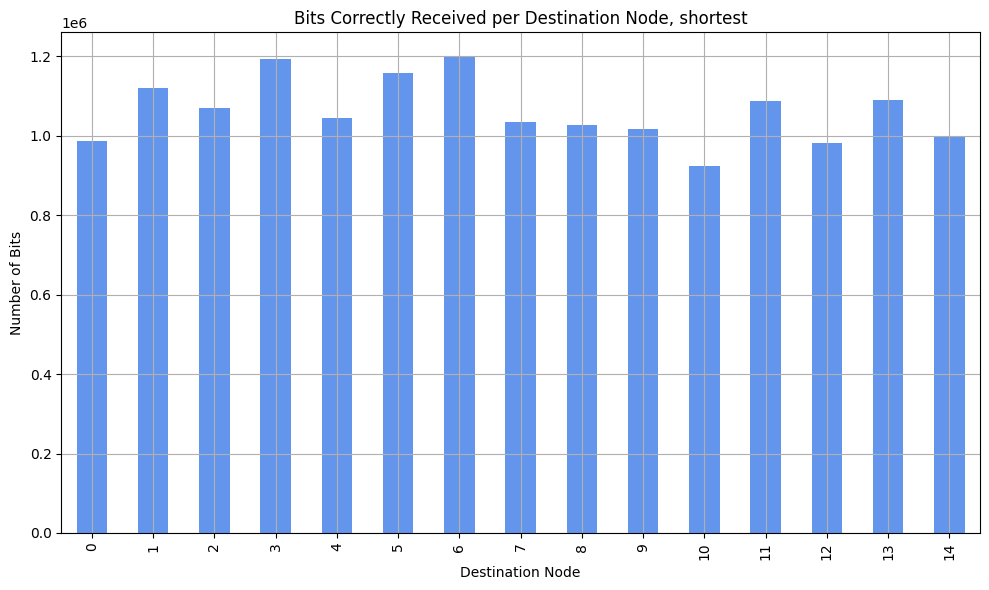

Number of correctly received packets per destination node:
Destination
0     7705
1     8988
2     8452
3     9608
4     8382
5     9143
6     9684
7     8155
8     8052
9     8185
10    7297
11    8532
12    7596
13    8558
14    7829
Name: count, dtype: int64


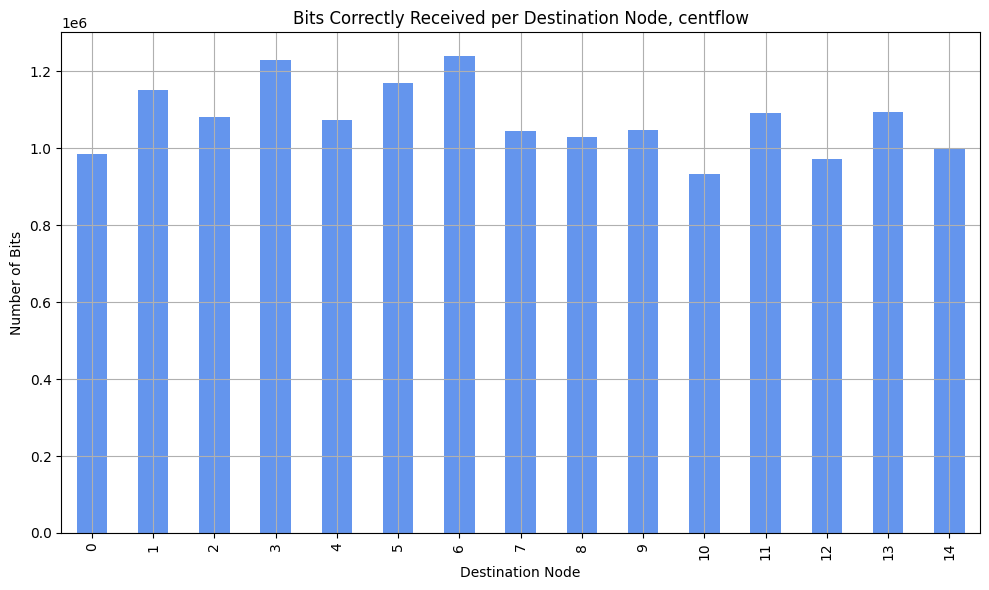

Number of correctly received packets per destination node:
Destination
0     7721
1     8756
2     8355
3     9329
4     8167
5     9058
6     9380
7     8082
8     8028
9     7940
10    7221
11    8497
12    7664
13    8522
14    7819
Name: count, dtype: int64


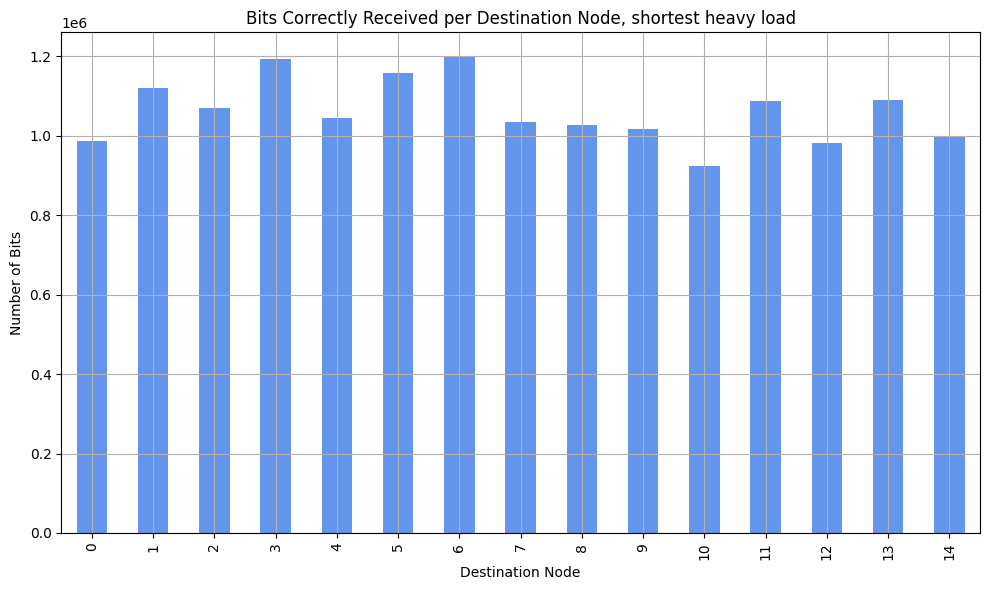

Number of correctly received packets per destination node:
Destination
0     1942
1     3223
2     1842
3     3001
4     2549
5     3188
6     3256
7     1727
8     1724
9     1697
10     896
11    1808
12    1651
13    1726
14    1670
Name: count, dtype: int64


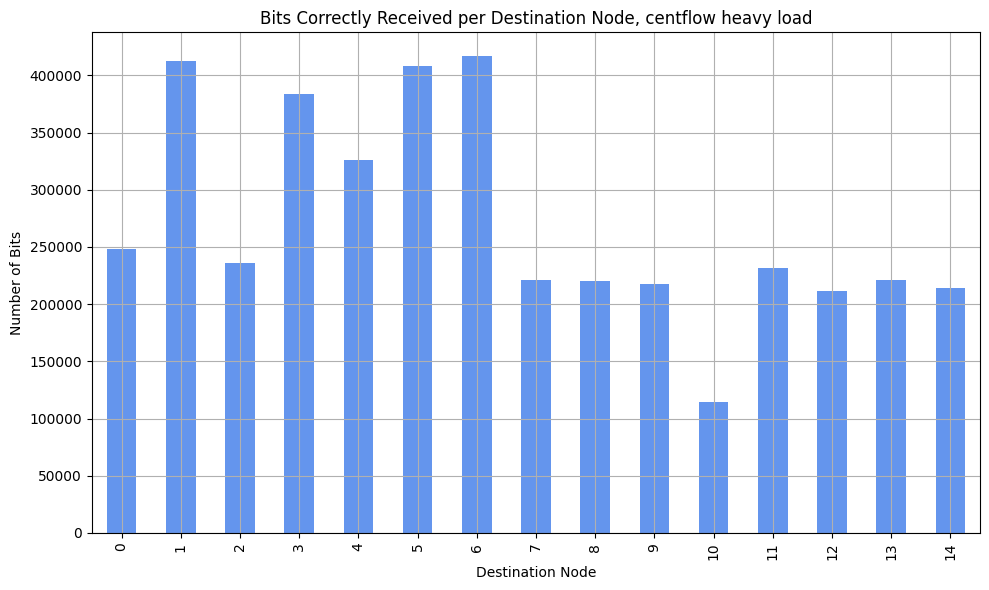

In [3]:
def num_received_bits(file, title):
    df_packets = pd.read_csv(file)
    df_packets["Destination"] = df_packets["Destination"].str.extract(r"(\d+)", expand=False).astype(int)

    # Filter only delivered packets
    delivered_packets = df_packets[df_packets["Delivered"] == True]

    # Count received packets per destination node
    received_counts = delivered_packets["Destination"].value_counts().sort_index()
    received_bits = received_counts * 128

    print("Number of correctly received packets per destination node:")
    print(received_counts)

    plt.figure(figsize=(10, 6))
    received_bits.plot(kind="bar", color="cornflowerblue")
    plt.title(f"Bits Correctly Received per Destination Node, {title}")
    plt.xlabel("Destination Node")
    plt.ylabel("Number of Bits")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

num_received_bits(f"{low_load_sim}packet_result.csv", "shortest")
num_received_bits(f'{low_load_sim_centflow}packet_result.csv', "centflow")
num_received_bits(f"{heavy_load_sim}packet_result.csv", "shortest heavy load")
num_received_bits(f'{heavy_load_sim_centflow}packet_result.csv', "centflow heavy load")

## Average of correctly received bits by destination nodes for paths of different lengths

In [4]:
with open(graph_path) as f:
    data = json.load(f)
G = nx.node_link_graph(data, edges="links") # type: ignore

all_pairs_lengths = dict(nx.all_pairs_shortest_path_length(G))

# Extract unique path lengths
unique_lengths = set()

for source, length_dict in all_pairs_lengths.items():
    for target, length in length_dict.items():
        if source != target:
            unique_lengths.add(length)

print("Unique shortest path lengths between node pairs:", sorted(unique_lengths))

Unique shortest path lengths between node pairs: [1, 2, 3, 4]


## Success probability for each path length

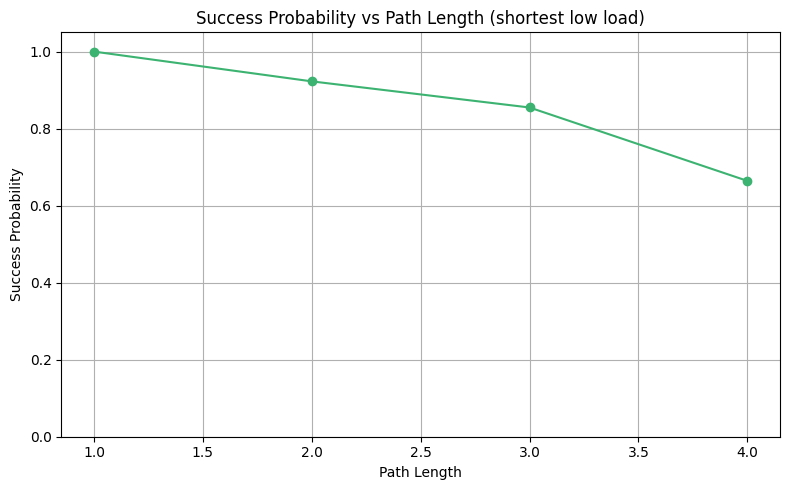

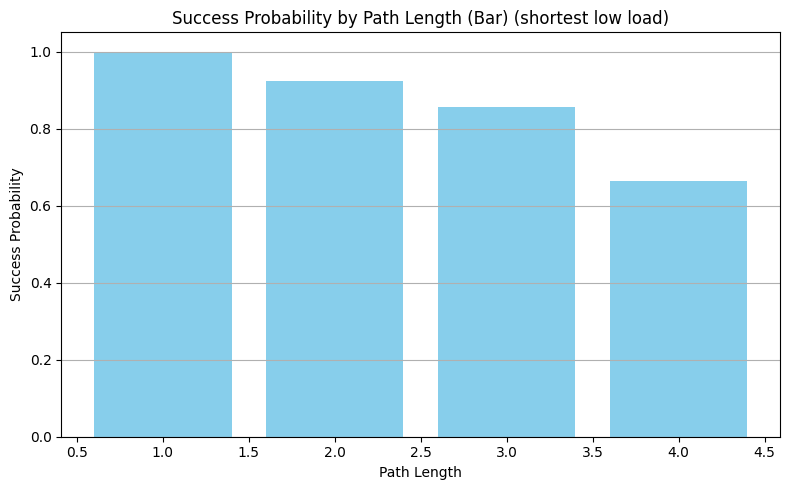

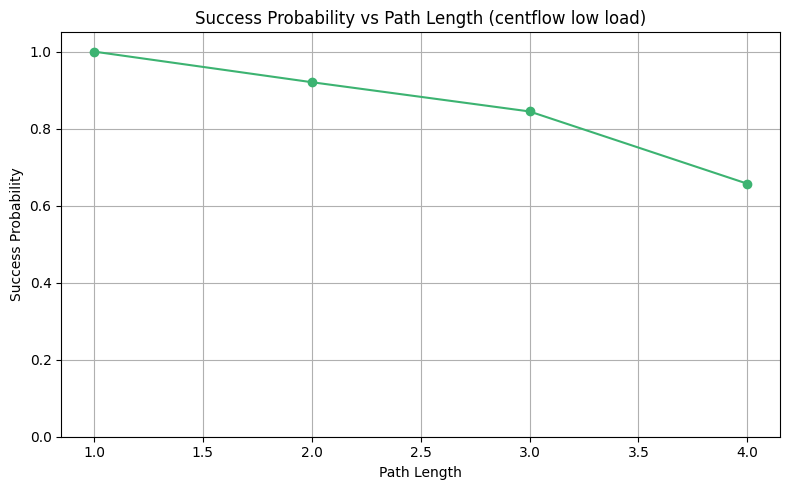

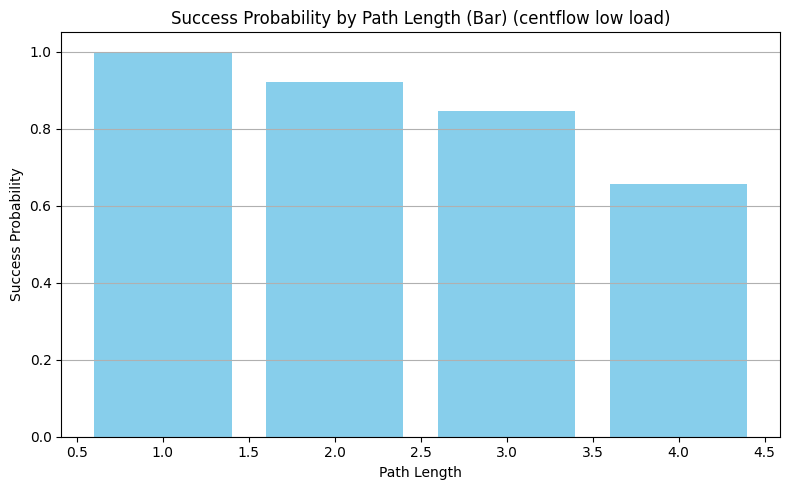

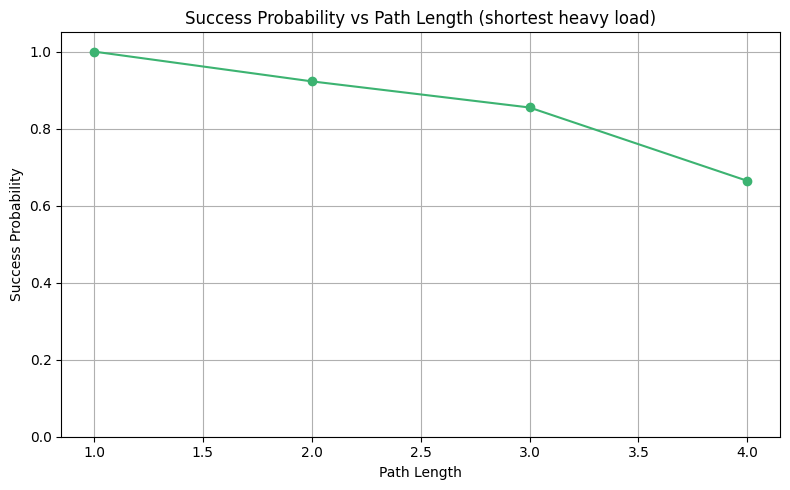

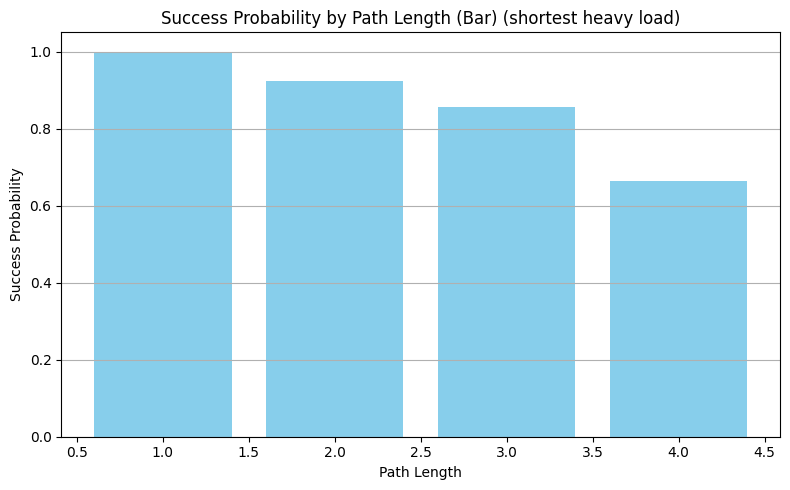

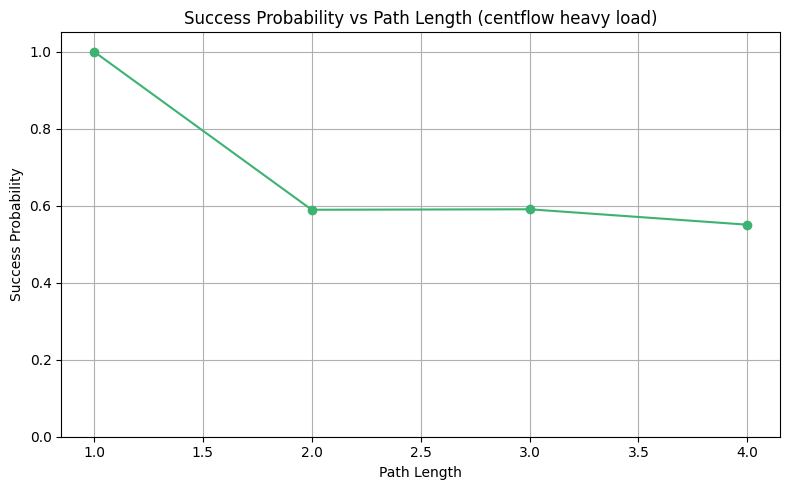

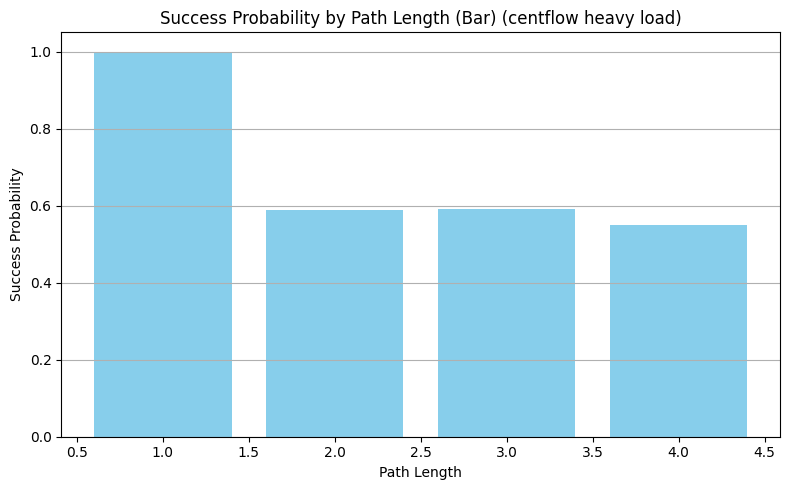

In [5]:
# Calculate and plot success probability for each path length

def success_probability_by_path_length(packet_file, graph_path, title):
    # Load packet results
    df = pd.read_csv(packet_file)
    df["Sent"] = df["Sent"].astype(bool)
    df["Delivered"] = df["Delivered"].astype(bool)

    # Load graph and compute shortest path lengths
    with open(graph_path) as f:
        data = json.load(f)
    G = nx.node_link_graph(data, edges="links") # type: ignore
    all_pairs_lengths = dict(nx.all_pairs_shortest_path_length(G))

    # Build a mapping from (source, dest) to path length
    path_length_dict = {}
    for src, targets in all_pairs_lengths.items():
        for dst, length in targets.items():
            if src != dst:
                path_length_dict[(str(src), str(dst))] = length

    # Add path length to each packet row
    def get_path_length(row):
        src = row["Source"].replace("node", "")
        dst = row["Destination"].replace("node", "")
        return path_length_dict.get((src, dst), None)
    df["path_length"] = df.apply(get_path_length, axis=1) # type: ignore

    # Filter only sent packets
    df_sent = df[df["Sent"] == True]

    # Group by path length and calculate success probability
    grouped = df_sent.groupby("path_length").agg(
        sent_packets=("Sent", "count"),
        delivered_packets=("Delivered", "sum")
    ).reset_index()
    grouped["success_probability"] = grouped["delivered_packets"] / grouped["sent_packets"]

    # Plot success probability by path length
    plt.figure(figsize=(8, 5))
    plt.plot(grouped["path_length"], grouped["success_probability"], marker="o", linestyle="-", color="mediumseagreen")
    plt.title(f"Success Probability vs Path Length ({title})")
    plt.xlabel("Path Length")
    plt.ylabel("Success Probability")
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Bar plot for better representation
    plt.figure(figsize=(8, 5))
    plt.bar(grouped["path_length"], grouped["success_probability"], color="skyblue")
    plt.title(f"Success Probability by Path Length (Bar) ({title})")
    plt.xlabel("Path Length")
    plt.ylabel("Success Probability")
    plt.ylim(0, 1.05)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

# Example usage for all four simulations:
success_probability_by_path_length(f"{low_load_sim}packet_result.csv", graph_path, "shortest low load")
success_probability_by_path_length(f"{low_load_sim_centflow}packet_result.csv", graph_path, "centflow low load")
success_probability_by_path_length(f"{heavy_load_sim}packet_result.csv", graph_path, "shortest heavy load")
success_probability_by_path_length(f"{heavy_load_sim_centflow}packet_result.csv", graph_path, "centflow heavy load")


## Centrality values for each node

This plot is useless for us, I did it for sport as we say in Italy.

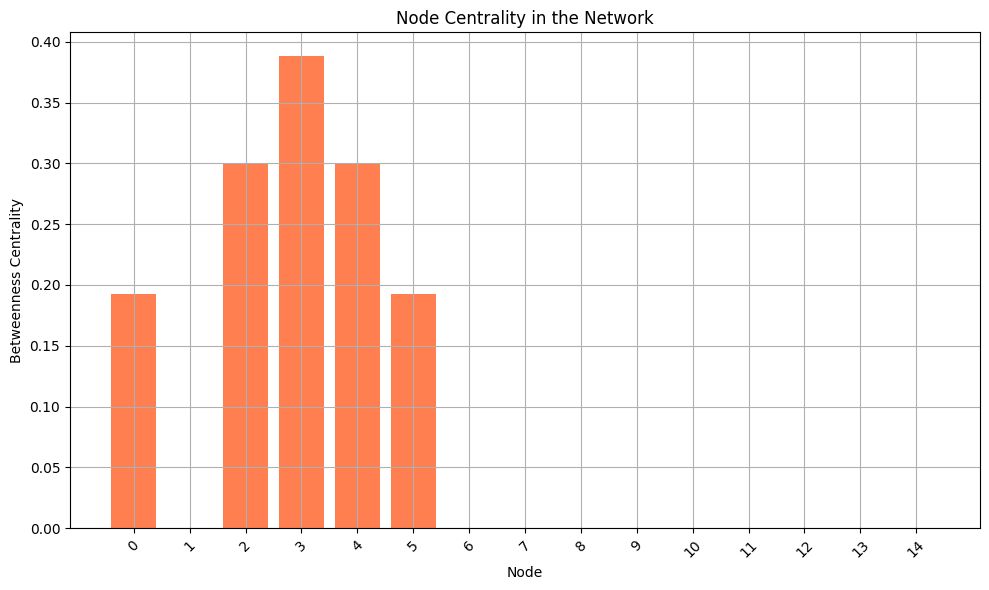

In [6]:
centrality = nx.betweenness_centrality(G)

plt.figure(figsize=(10, 6))
plt.bar(list(centrality.keys()), list(centrality.values()), color="coral")
plt.xlabel("Node")
plt.ylabel("Betweenness Centrality")
plt.title("Node Centrality in the Network")
plt.xticks(ticks=range(len(centrality)), labels=list(centrality.keys()), rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()